# Exploratory Data Analysis on Global Superstore

**Note: keep `Global_Superstore2.csv` in the same folder as this notebook (it is included). Install libraries first with `pip install -r requirements.txt`. In Google Colab, upload the CSV in the Files panel first.**

**Task 1 - Retail EDA**

**Objective:** Do a full EDA on the Global Superstore retail dataset and find patterns, trends and business insights using statistics and charts.

**Dataset:** Global_Superstore2.csv (51,290 orders, 24 columns, 2011 to 2014)

**Sections**
1. Data Understanding
2. Data Cleaning
3. Statistical Summary
4. Visualizations (10 charts + extra)
5. Key Insights
6. Business Recommendations

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

os.makedirs('images', exist_ok=True)

## 1. Data Understanding

### 1.1 Load the data and look at shape, dtypes, first and last 5 rows

In [2]:
df = pd.read_csv('Global_Superstore2.csv', encoding='latin-1')

print('Shape:', df.shape)
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])

Shape: (51290, 24)
Rows: 51290
Columns: 24


In [3]:
print(df.dtypes)

Row ID              int64
Order ID              str
Order Date            str
Ship Date             str
Ship Mode             str
Customer ID           str
Customer Name         str
Segment               str
City                  str
State                 str
Country               str
Postal Code       float64
Market                str
Region                str
Product ID            str
Category              str
Sub-Category          str
Product Name          str
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
Shipping Cost     float64
Order Priority        str
dtype: object


In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31/07/2012,31/07/2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05/02/2013,07/02/2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17/10/2013,18/10/2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28/01/2013,30/01/2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05/11/2013,06/11/2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [5]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
51285,29002,IN-2014-62366,19/06/2014,19/06/2014,Same Day,KE-16420,Katrina Edelman,Corporate,Kure,Hiroshima,...,OFF-FA-10000746,Office Supplies,Fasteners,"Advantus Thumb Tacks, 12 Pack",65.100,5,0.0,4.5000,0.01,Medium
51286,35398,US-2014-102288,20/06/2014,24/06/2014,Standard Class,ZC-21910,Zuschuss Carroll,Consumer,Houston,Texas,...,OFF-AP-10002906,Office Supplies,Appliances,Hoover Replacement Belt for Commercial Guardsm...,0.444,1,0.8,-1.1100,0.01,Medium
51287,40470,US-2013-155768,02/12/2013,02/12/2013,Same Day,LB-16795,Laurel Beltran,Home Office,Oxnard,California,...,OFF-EN-10001219,Office Supplies,Envelopes,"#10- 4 1/8"" x 9 1/2"" Security-Tint Envelopes",22.920,3,0.0,11.2308,0.01,High
51288,9596,MX-2012-140767,18/02/2012,22/02/2012,Standard Class,RB-19795,Ross Baird,Home Office,Valinhos,São Paulo,...,OFF-BI-10000806,Office Supplies,Binders,"Acco Index Tab, Economy",13.440,2,0.0,2.4000,0.00,Medium
51289,6147,MX-2012-134460,22/05/2012,26/05/2012,Second Class,MC-18100,Mick Crebagga,Consumer,Tipitapa,Managua,...,OFF-PA-10004155,Office Supplies,Paper,"Eaton Computer Printout Paper, 8.5 x 11",61.380,3,0.0,1.8000,0.00,High


### 1.2 Data profile (column type, non-null count, unique values)

In [6]:
profile = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'non_null': df.count(),
    'null': df.isnull().sum(),
    'unique': df.nunique()
})
profile

,dtype,non_null,null,unique
Row ID,int64,51290,0,51290
Order ID,str,51290,0,25035
Order Date,str,51290,0,1430
Ship Date,str,51290,0,1464
Ship Mode,str,51290,0,4
Customer ID,str,51290,0,1590
Customer Name,str,51290,0,795
Segment,str,51290,0,3
City,str,51290,0,3636
State,str,51290,0,1094


### 1.3 Target variables and feature types

- **Target variables:** `Sales` and `Profit` (these are what the business cares about)
- **Numerical:** Sales, Quantity, Discount, Profit, Shipping Cost
- **Categorical:** Ship Mode, Segment, Market, Region, Country, State, City, Category, Sub-Category, Order Priority
- **Temporal:** Order Date, Ship Date
- **ID columns:** Row ID, Order ID, Customer ID, Product ID (not used for analysis)

In [7]:
target_cols = ['Sales', 'Profit']
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost']
cat_cols = ['Ship Mode', 'Segment', 'Market', 'Region', 'Country', 'State', 'City', 'Category', 'Sub-Category', 'Order Priority']
date_cols = ['Order Date', 'Ship Date']

print('Numerical:', num_cols)
print('Categorical:', cat_cols)
print('Temporal:', date_cols)

Numerical: ['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost']
Categorical: ['Ship Mode', 'Segment', 'Market', 'Region', 'Country', 'State', 'City', 'Category', 'Sub-Category', 'Order Priority']
Temporal: ['Order Date', 'Ship Date']


## 2. Data Cleaning

### 2.1 Missing values (count and percentage)

In [8]:
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': (df.isnull().sum() / len(df) * 100).round(2)
})
missing[missing['missing_count'] > 0]

,missing_count,missing_percent
Postal Code,41296,80.51


Only **Postal Code** has missing values and it is missing for about 80% of rows. Postal codes exist only for United States orders, so this is not a data error. It is not useful for analysis, so I drop this column.

In [9]:
df = df.drop(columns=['Postal Code'])
print('Missing values left:', df.isnull().sum().sum())
print(df.shape)

Missing values left: 0
(51290, 23)


### 2.2 Fix data types (dates)

In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()
df['Quarter'] = df['Order Date'].dt.quarter
df['Ship Days'] = (df['Ship Date'] - df['Order Date']).dt.days

print(df[['Order Date', 'Ship Date']].dtypes)
print('Date range:', df['Order Date'].min(), 'to', df['Order Date'].max())

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object
Date range: 2011-01-01 00:00:00 to 2014-12-31 00:00:00


### 2.3 Duplicate rows

In [11]:
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate Row IDs:', df['Row ID'].duplicated().sum())
df = df.drop_duplicates()
print('Shape after removing duplicates:', df.shape)

Duplicate rows: 0
Duplicate Row IDs: 0


Shape after removing duplicates: (51290, 28)


### 2.4 Outliers using the IQR method

Rule: a value is an outlier if it is below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR`.

Sales and Profit are real orders (big orders are real business), so I do **not delete** these rows. I count them and make capped columns (`Sales_capped`, `Profit_capped`, `Quantity_capped`) to use where outliers would hide the pattern.

In [12]:
def find_outliers(col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    count = ((df[col] < low) | (df[col] > high)).sum()
    return [col, q1, q3, iqr, low, high, count, round(count / len(df) * 100, 2)]

rows = []
for c in ['Sales', 'Profit', 'Quantity']:
    rows.append(find_outliers(c))

outlier_table = pd.DataFrame(rows, columns=['Column', 'Q1', 'Q3', 'IQR', 'Lower Limit', 'Upper Limit', 'Outlier Count', 'Outlier %'])
outlier_table

,Column,Q1,Q3,IQR,Lower Limit,Upper Limit,Outlier Count,Outlier %
0,Sales,30.758625,251.0532,220.294575,-299.683238,581.495063,5655,11.03
1,Profit,0.000000,36.8100,36.810000,-55.215000,92.025000,9755,19.02
2,Quantity,2.000000,5.0000,3.000000,-2.500000,9.500000,877,1.71


In [13]:
for c in ['Sales', 'Profit', 'Quantity']:
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    iqr = q3 - q1
    df[c + '_capped'] = df[c].clip(q1 - 1.5 * iqr, q3 + 1.5 * iqr)

df[['Sales', 'Sales_capped', 'Profit', 'Profit_capped', 'Quantity', 'Quantity_capped']].describe()

,Sales,Sales_capped,Profit,Profit_capped,Quantity,Quantity_capped
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.490581,172.359178,28.610982,18.092440,3.476545,3.438731
std,487.565361,190.096672,174.340972,39.851666,2.278766,2.147765
min,0.444000,0.444000,-6599.978000,-55.215000,1.000000,1.000000
25%,30.758625,30.758625,0.000000,0.000000,2.000000,2.000000
50%,85.053000,85.053000,9.240000,9.240000,3.000000,3.000000
75%,251.053200,251.053200,36.810000,36.810000,5.000000,5.000000
max,22638.480000,581.495063,8399.976000,92.025000,14.000000,9.500000


## 3. Statistical Summary

### 3.1 Descriptive statistics

In [14]:
df[num_cols].describe().round(2)

,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00,51290.00,51290.00,51290.00,51290.00
mean,246.49,3.48,0.14,28.61,26.38
std,487.57,2.28,0.21,174.34,57.30
min,0.44,1.00,0.00,-6599.98,0.00
25%,30.76,2.00,0.00,0.00,2.61
50%,85.05,3.00,0.00,9.24,7.79
75%,251.05,5.00,0.20,36.81,24.45
max,22638.48,14.00,0.85,8399.98,933.57


In [15]:
print('Median values:')
print(df[num_cols].median().round(2))

Median values:
Sales            85.05
Quantity          3.00
Discount          0.00
Profit            9.24
Shipping Cost     7.79
dtype: float64


### 3.2 Skewness and kurtosis

In [16]:
skew_kurt = pd.DataFrame({
    'Skewness': df[num_cols].skew(),
    'Kurtosis': df[num_cols].kurt()
}).round(2)
skew_kurt

,Skewness,Kurtosis
Sales,8.14,176.73
Quantity,1.36,2.28
Discount,1.39,0.72
Profit,4.16,291.41
Shipping Cost,5.86,50.02


- **Sales** and **Shipping Cost** are strongly right skewed with very high kurtosis. A few huge orders pull the mean far above the median.
- **Profit** has very high kurtosis, so it has heavy tails on both sides (big profits and big losses).
- **Discount** is right skewed because most orders have little or no discount.
- **Quantity** is mildly right skewed.

### 3.3 Correlation matrix

               Sales  Quantity  Discount  Profit  Shipping Cost
Sales           1.00      0.31     -0.09    0.48           0.77
Quantity        0.31      1.00     -0.02    0.10           0.27
Discount       -0.09     -0.02      1.00   -0.32          -0.08
Profit          0.48      0.10     -0.32    1.00           0.35
Shipping Cost   0.77      0.27     -0.08    0.35           1.00


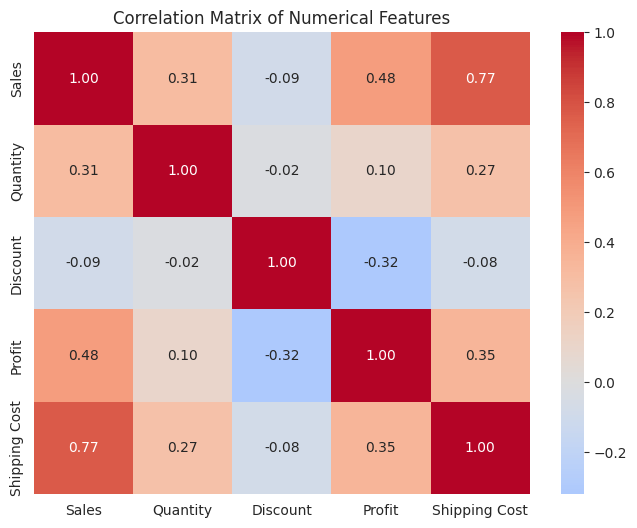

In [17]:
corr = df[num_cols].corr().round(2)
print(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.savefig('images/00_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

- Sales and Shipping Cost have a strong positive correlation (bigger orders cost more to ship).
- Sales and Profit have a positive but moderate correlation.
- Discount and Profit have a negative correlation (more discount, less profit).

## 4. Visualizations

### Chart 1: Sales distribution histogram

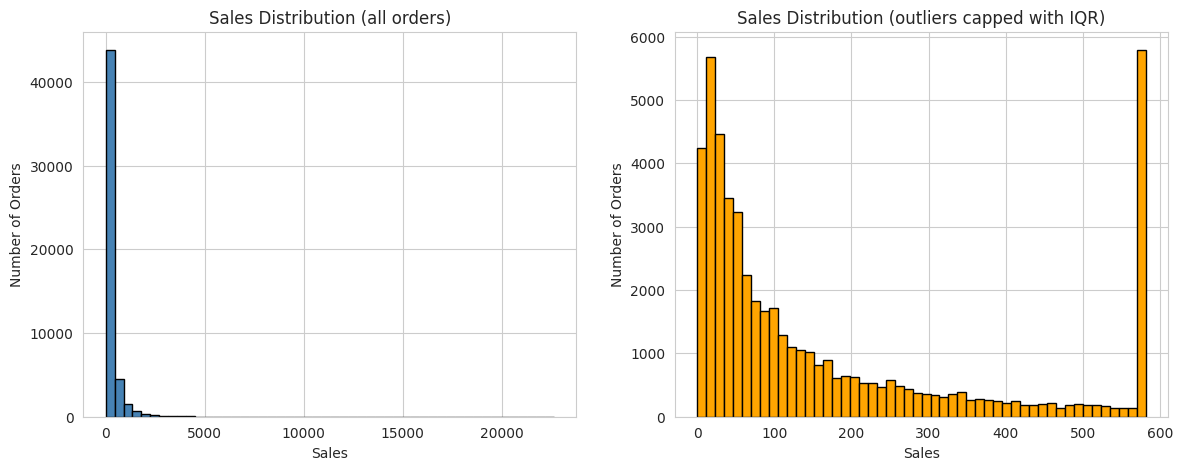

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(df['Sales'], bins=50, color='steelblue', edgecolor='black')
ax[0].set_title('Sales Distribution (all orders)')
ax[0].set_xlabel('Sales')
ax[0].set_ylabel('Number of Orders')

ax[1].hist(df['Sales_capped'], bins=50, color='orange', edgecolor='black')
ax[1].set_title('Sales Distribution (outliers capped with IQR)')
ax[1].set_xlabel('Sales')
ax[1].set_ylabel('Number of Orders')

plt.savefig('images/01_sales_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Most orders are small (under about 300). The raw histogram is stretched by a few very large orders, so the capped version shows the shape better.

### Chart 2: Profit by Category

Category
Technology         663778.73
Office Supplies    518473.83
Furniture          285204.72
Name: Profit, dtype: float64


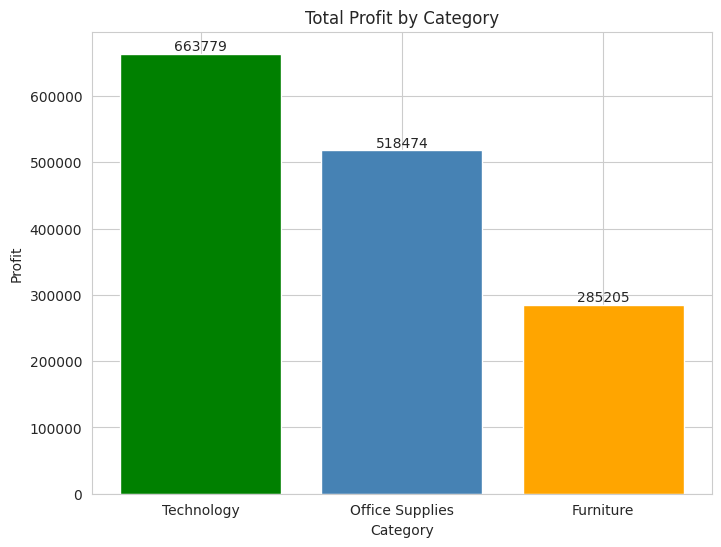

In [19]:
cat_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print(cat_profit.round(2))

plt.figure(figsize=(8, 6))
bars = plt.bar(cat_profit.index, cat_profit.values, color=['green', 'steelblue', 'orange'])
plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
for b in bars:
    plt.text(b.get_x() + b.get_width() / 2, b.get_height(), round(b.get_height()), ha='center', va='bottom')
plt.savefig('images/02_profit_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 3: Monthly sales trend

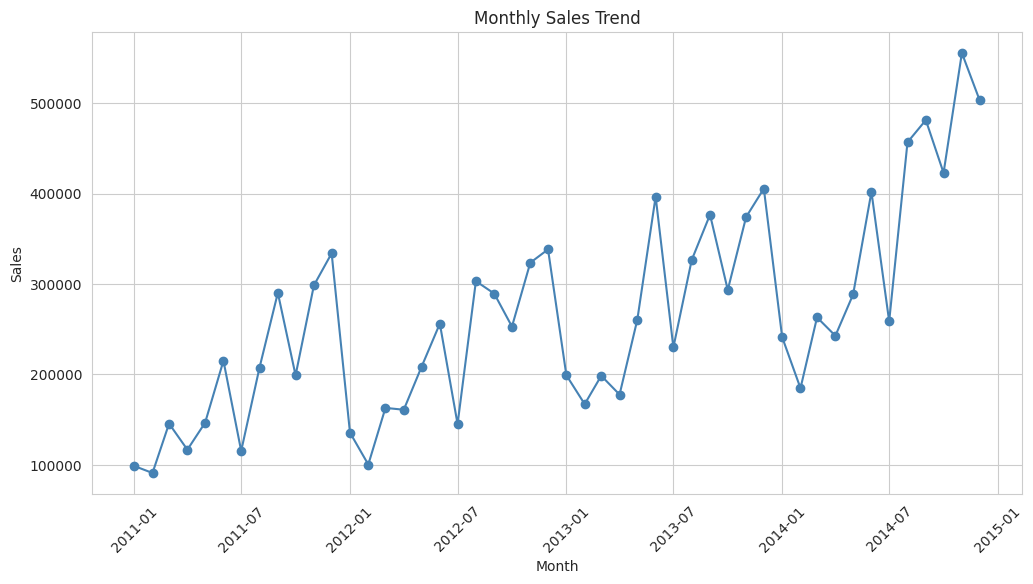

In [20]:
df['YearMonth'] = df['Order Date'].dt.to_period('M')
monthly = df.groupby('YearMonth')[['Sales', 'Profit']].sum()
monthly.index = monthly.index.to_timestamp()

plt.figure(figsize=(12, 6))
plt.plot(monthly.index, monthly['Sales'], marker='o', color='steelblue')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.savefig('images/03_monthly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 4: Regional sales comparison

Region
Central           2822302.52
South             1600907.04
North             1248165.60
Oceania           1100184.61
Southeast Asia     884423.17
North Asia         848309.78
EMEA               806161.31
Africa             783773.21
Central Asia       752826.57
West               725457.82
East               678781.24
Caribbean          324280.86
Canada              66928.17
Name: Sales, dtype: float64


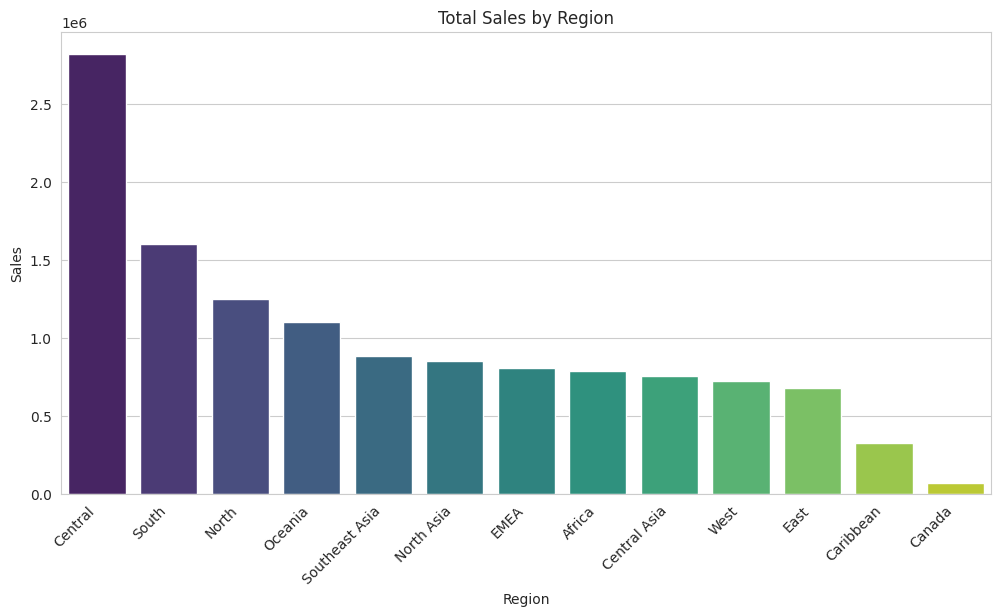

In [21]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(region_sales.round(2))

plt.figure(figsize=(12, 6))
sns.barplot(x=region_sales.index, y=region_sales.values, palette='viridis')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.xticks(rotation=45, ha='right')
plt.savefig('images/04_regional_sales.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 5: Top 10 products by sales

Product Name
Apple Smart Phone, Full Size                                86935.78
Cisco Smart Phone, Full Size                                76441.53
Motorola Smart Phone, Full Size                             73156.30
Nokia Smart Phone, Full Size                                71904.56
Canon imageCLASS 2200 Advanced Copier                       61599.82
Hon Executive Leather Armchair, Adjustable                  58193.48
Office Star Executive Leather Armchair, Adjustable          50661.68
Harbour Creations Executive Leather Armchair, Adjustable    50121.52
Samsung Smart Phone, Cordless                               48653.46
Nokia Smart Phone, with Caller ID                           47877.79
Name: Sales, dtype: float64


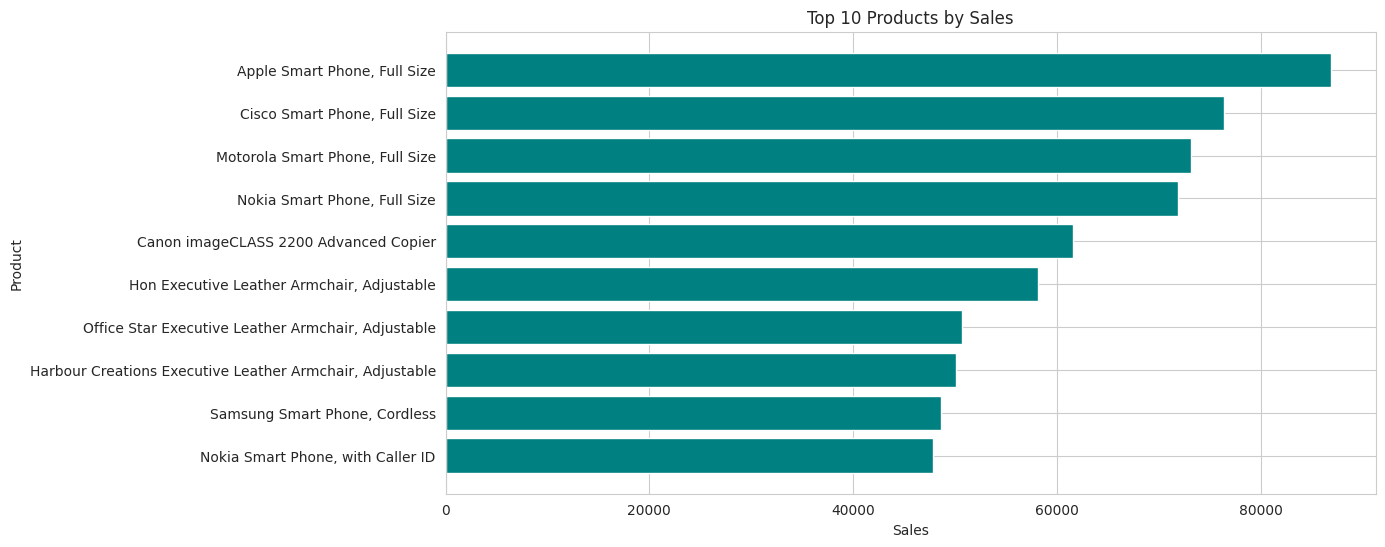

In [22]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_products.round(2))

plt.figure(figsize=(12, 6))
plt.barh(top_products.index[::-1], top_products.values[::-1], color='teal')
plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.ylabel('Product')
plt.savefig('images/05_top10_products.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 6: Discount vs Profit scatter plot

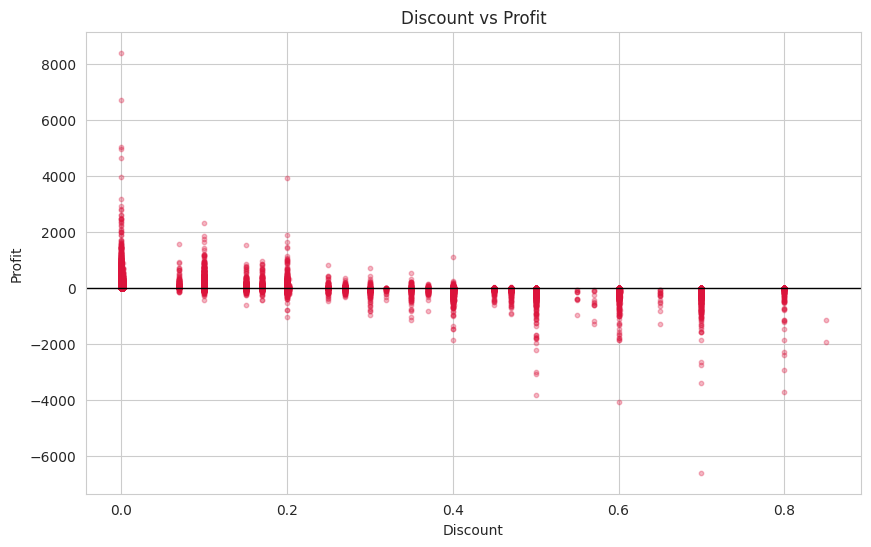

In [23]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Discount'], df['Profit'], alpha=0.3, color='crimson', s=10)
plt.axhline(0, color='black', linewidth=1)
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.savefig('images/06_discount_vs_profit.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 7: Quantity distribution by shipping mode (box plot)

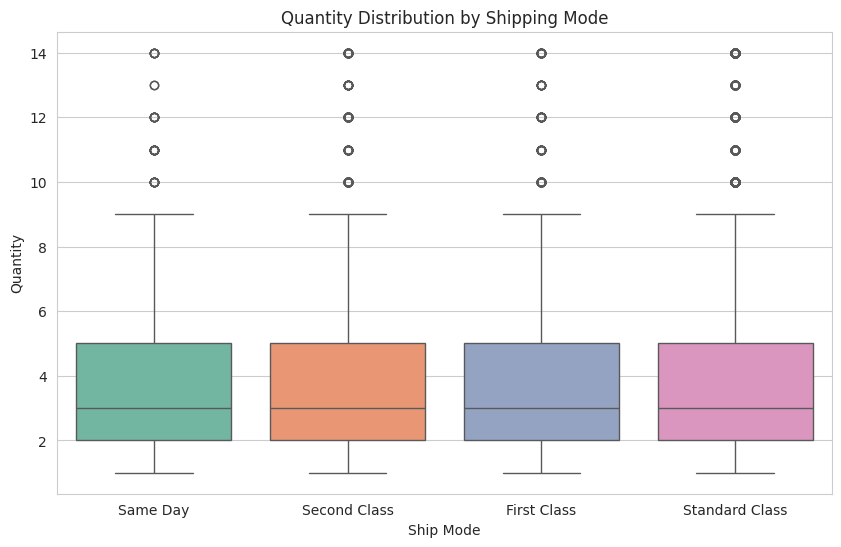

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Ship Mode', y='Quantity', data=df, palette='Set2')
plt.title('Quantity Distribution by Shipping Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Quantity')
plt.savefig('images/07_quantity_by_shipmode.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 8: Category vs Sub-Category heatmap (average profit)

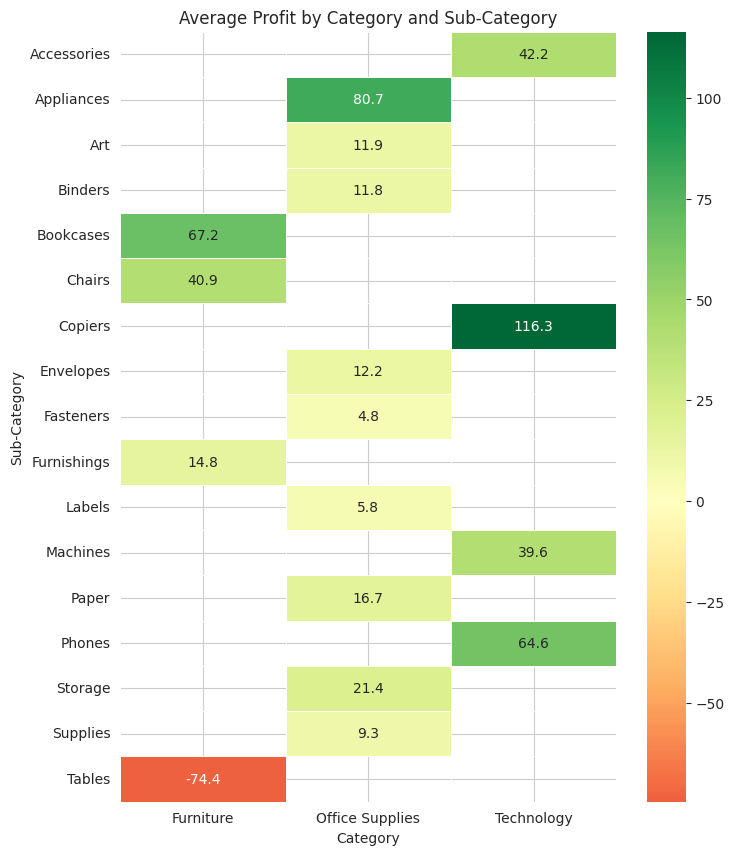

In [25]:
pivot = df.pivot_table(values='Profit', index='Sub-Category', columns='Category', aggfunc='mean')

plt.figure(figsize=(8, 10))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Average Profit by Category and Sub-Category')
plt.savefig('images/08_category_subcategory_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 9: Customer segment pie chart

Segment
Consumer       26518
Corporate      15429
Home Office     9343
Name: count, dtype: int64


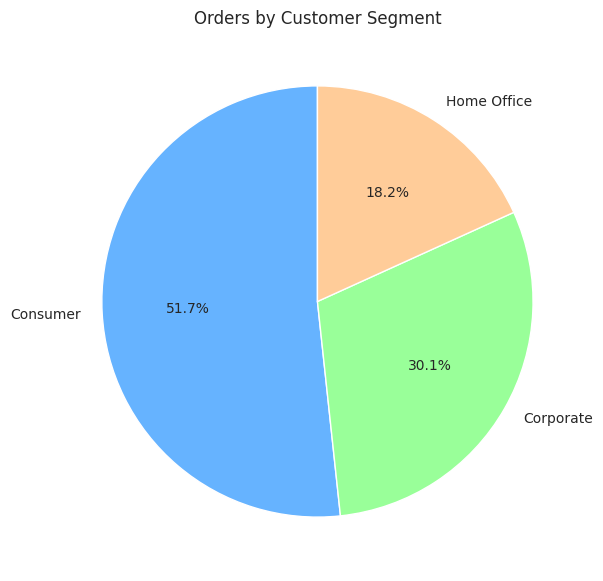

In [26]:
seg = df['Segment'].value_counts()
print(seg)

plt.figure(figsize=(7, 7))
plt.pie(seg.values, labels=seg.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#99ff99', '#ffcc99'])
plt.title('Orders by Customer Segment')
plt.savefig('images/09_segment_pie.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 10: Monthly sales vs profit (dual-axis line chart)

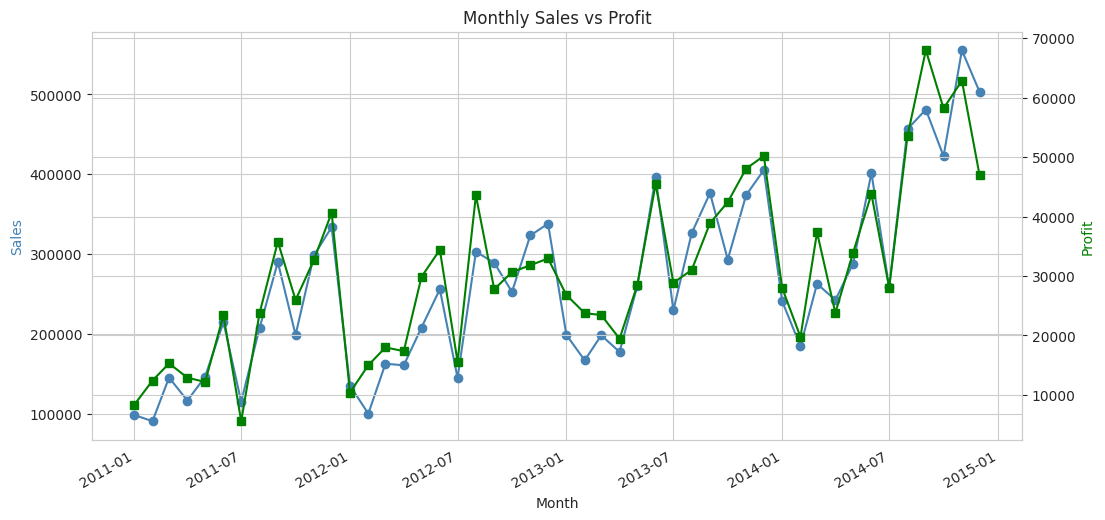

In [27]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(monthly.index, monthly['Sales'], color='steelblue', marker='o', label='Sales')
ax1.set_xlabel('Month')
ax1.set_ylabel('Sales', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly['Profit'], color='green', marker='s', label='Profit')
ax2.set_ylabel('Profit', color='green')

plt.title('Monthly Sales vs Profit')
fig.autofmt_xdate()
plt.savefig('images/10_monthly_sales_vs_profit.png', dpi=150, bbox_inches='tight')
plt.show()

### Extra charts (used in the insights)

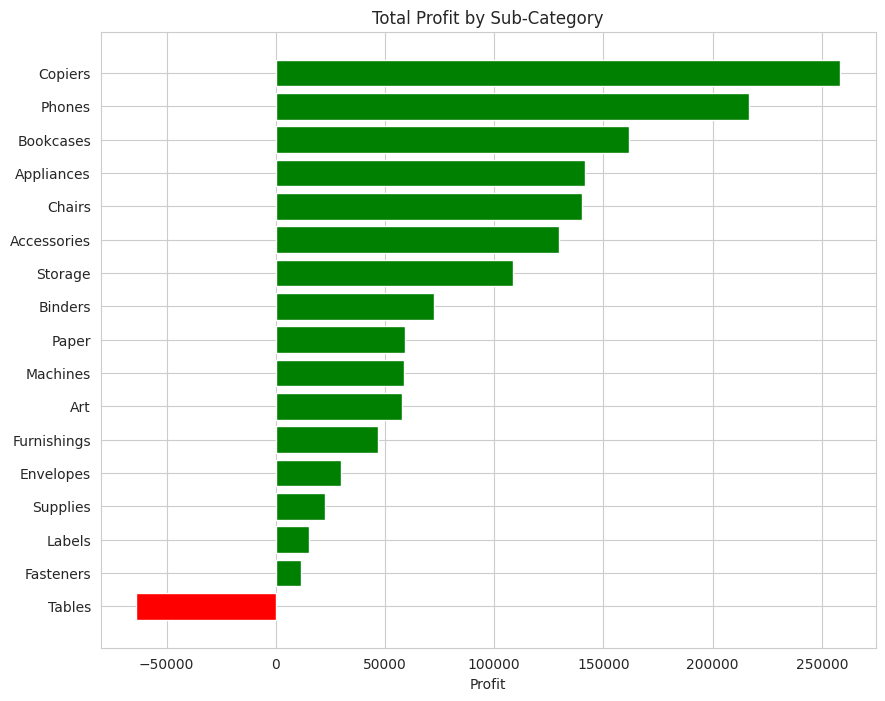

In [28]:
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

plt.figure(figsize=(10, 8))
colors = ['red' if x < 0 else 'green' for x in sub_profit.values]
plt.barh(sub_profit.index, sub_profit.values, color=colors)
plt.title('Total Profit by Sub-Category')
plt.xlabel('Profit')
plt.savefig('images/11_profit_by_subcategory.png', dpi=150, bbox_inches='tight')
plt.show()

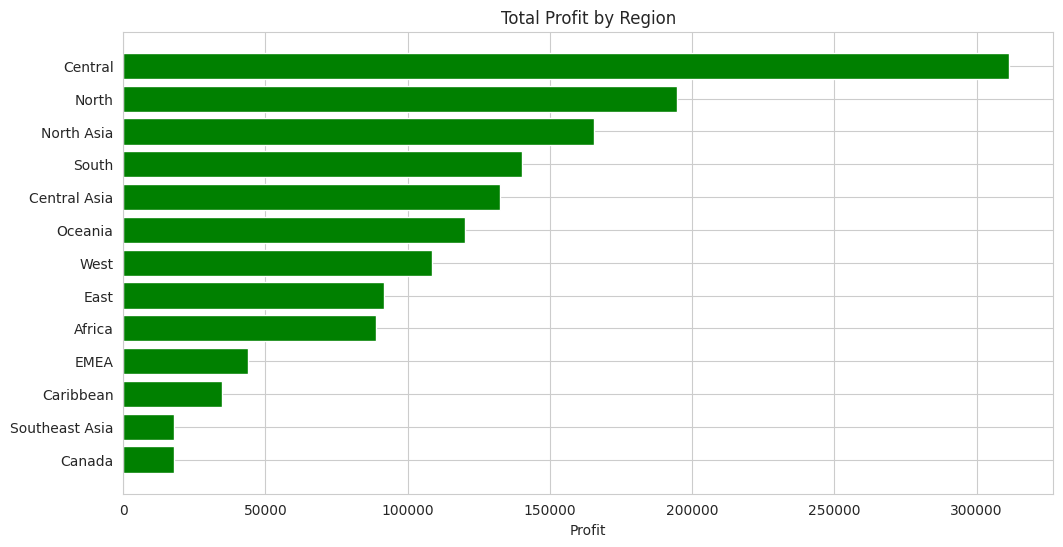

In [29]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values()

plt.figure(figsize=(12, 6))
colors = ['red' if x < 0 else 'green' for x in region_profit.values]
plt.barh(region_profit.index, region_profit.values, color=colors)
plt.title('Total Profit by Region')
plt.xlabel('Profit')
plt.savefig('images/12_profit_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

Discount Group
0%         61.04
1-10%      72.28
11-20%     27.61
21-30%    -21.88
31-50%    -61.55
51-100%   -98.89
Name: Profit, dtype: float64


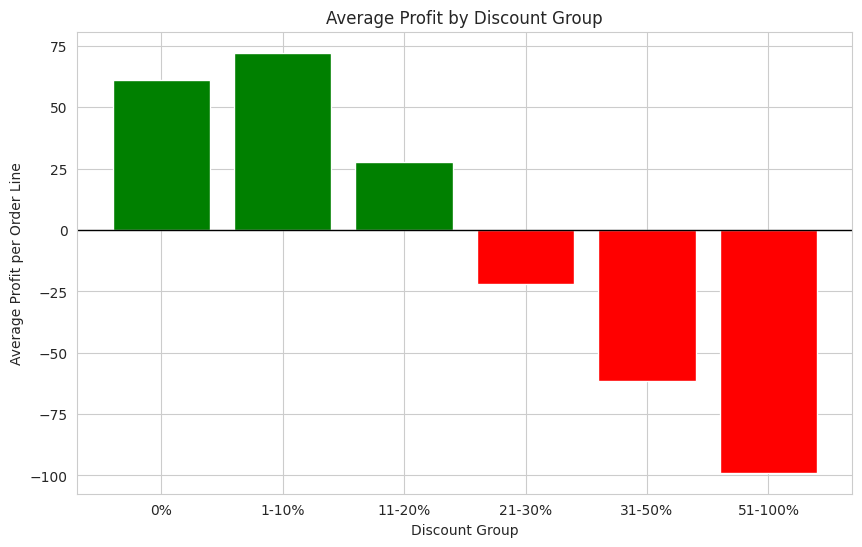

In [30]:
df['Discount Group'] = pd.cut(df['Discount'], bins=[-0.01, 0, 0.1, 0.2, 0.3, 0.5, 1.0],
                              labels=['0%', '1-10%', '11-20%', '21-30%', '31-50%', '51-100%'])
disc_profit = df.groupby('Discount Group')['Profit'].mean()
print(disc_profit.round(2))

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in disc_profit.values]
plt.bar(disc_profit.index.astype(str), disc_profit.values, color=colors)
plt.axhline(0, color='black', linewidth=1)
plt.title('Average Profit by Discount Group')
plt.xlabel('Discount Group')
plt.ylabel('Average Profit per Order Line')
plt.savefig('images/13_profit_by_discount_group.png', dpi=150, bbox_inches='tight')
plt.show()

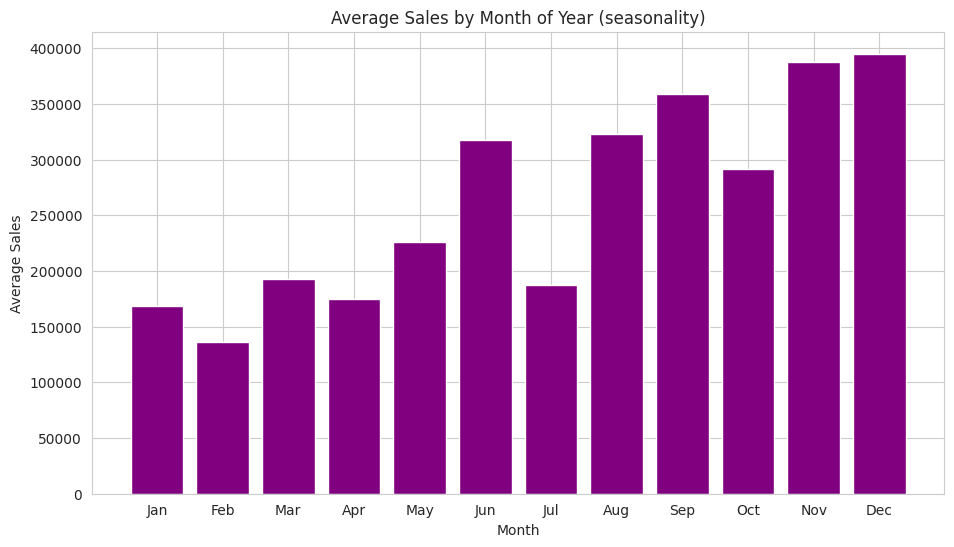

In [31]:
month_avg = df.groupby('Month')['Sales'].sum() / df['Year'].nunique()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(11, 6))
plt.bar(month_names, month_avg.values, color='purple')
plt.title('Average Sales by Month of Year (seasonality)')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.savefig('images/14_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Key Insights

### 5.1 Top 3 most profitable product categories

In [32]:
cat_table = df.groupby('Category').agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'))
cat_table['Margin %'] = (cat_table['Profit'] / cat_table['Sales'] * 100).round(2)
cat_table = cat_table.sort_values('Profit', ascending=False).round(2)
print(cat_table)

print()
print('Top 3 sub-categories by profit:')
top3_sub = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).head(3).round(2)
print(top3_sub)

print()
print('Loss making sub-categories:')
sub_all = df.groupby('Sub-Category')['Profit'].sum().round(2)
print(sub_all[sub_all < 0])

                      Sales     Profit  Margin %
Category                                        
Technology       4744557.50  663778.73     13.99
Office Supplies  3787070.23  518473.83     13.69
Furniture        4110874.19  285204.72      6.94

Top 3 sub-categories by profit:
Sub-Category
Copiers      258567.55
Phones       216717.01
Bookcases    161924.42
Name: Profit, dtype: float64

Loss making sub-categories:
Sub-Category
Tables   -64083.39
Name: Profit, dtype: float64


### 5.2 Which regions are underperforming?

In [33]:
region_table = df.groupby('Region').agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'), Orders=('Order ID', 'nunique'))
region_table['Margin %'] = (region_table['Profit'] / region_table['Sales'] * 100).round(2)
region_table = region_table.sort_values('Margin %').round(2)
region_table

,Sales,Profit,Orders,Margin %
Region,,,,
Southeast Asia,884423.17,17852.33,1517,2.02
EMEA,806161.31,43897.97,2462,5.45
South,1600907.04,140355.77,3270,8.77
Caribbean,324280.86,34571.32,855,10.66
Oceania,1100184.61,120089.11,1744,10.92
Central,2822302.52,311403.98,5249,11.03
Africa,783773.21,88871.63,2232,11.34
East,678781.24,91522.78,1401,13.48
West,725457.82,108418.45,1611,14.94


In [34]:
print('Loss making countries (top 10 worst):')
country_profit = df.groupby('Country')['Profit'].sum().sort_values()
print(country_profit.head(10).round(2))

Loss making countries (top 10 worst):
Country
Turkey        -98447.23
Nigeria       -80750.72
Netherlands   -41070.07
Honduras      -29482.37
Pakistan      -22446.65
Argentina     -18693.80
Panama        -17723.45
Sweden        -17519.37
Philippines   -16128.22
South Korea   -12792.83
Name: Profit, dtype: float64


### 5.3 Relationship between discount and profit

In [35]:
print('Correlation (Discount, Profit):', round(df['Discount'].corr(df['Profit']), 3))
print()
disc_table = df.groupby('Discount Group').agg(Avg_Profit=('Profit', 'mean'), Total_Profit=('Profit', 'sum'), Rows=('Profit', 'count'))
print(disc_table.round(2))
print()
print('Share of rows with a loss:')
print(df.groupby('Discount Group').apply(lambda x: round((x['Profit'] < 0).mean() * 100, 1)))

Correlation (Discount, Profit): -0.316

                Avg_Profit  Total_Profit   Rows
Discount Group                                 
0%                   61.04    1770695.27  29009
1-10%                72.28     338189.26   4679
11-20%               27.61     173254.84   6274
21-30%              -21.88     -21155.61    967
31-50%              -61.55    -380944.82   6189
51-100%             -98.89    -412581.66   4172

Share of rows with a loss:
Discount Group
0%           0.0
1-10%       19.3
11-20%      23.3
21-30%      62.2
31-50%      87.4
51-100%    100.0
dtype: float64


### 5.4 Seasonal sales pattern

In [36]:
season = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
season_avg = season.groupby('Month')['Sales'].mean().round(0)
print(season_avg)
print()
q_sales = df.groupby('Quarter')['Sales'].sum()
print((q_sales / q_sales.sum() * 100).round(1))
print()
print('Yearly sales and profit:')
print(df.groupby('Year')[['Sales', 'Profit']].sum().round(0))

Month
1     168783.0
2     135935.0
3     192625.0
4     174640.0
5     226003.0
6     317429.0
7     187345.0
8     323458.0
9     359345.0
10    292046.0
11    387819.0
12    395195.0
Name: Sales, dtype: float64

Quarter
1    15.7
2    22.7
3    27.5
4    34.0
Name: Sales, dtype: float64

Yearly sales and profit:
          Sales    Profit
Year                     
2011  2259451.0  248941.0
2012  2677439.0  307415.0
2013  3405746.0  406935.0
2014  4299866.0  504166.0


### 5.5 A few more checks for the recommendations

In [37]:
print('Overall sales:', round(df['Sales'].sum()))
print('Overall profit:', round(df['Profit'].sum()))
print('Overall margin %:', round(df['Profit'].sum() / df['Sales'].sum() * 100, 2))
print()
print('Segment profit:')
print(df.groupby('Segment')['Profit'].sum().round(0))
print()
print('Market profit and margin:')
m = df.groupby('Market').agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'))
m['Margin %'] = (m['Profit'] / m['Sales'] * 100).round(2)
print(m.round(0))
print()
print('Ship mode avg shipping cost and ship days:')
print(df.groupby('Ship Mode')[['Shipping Cost', 'Ship Days']].mean().round(2))
print()
print('Tables sub-category:')
t = df[df['Sub-Category'] == 'Tables']
print('Avg discount:', round(t['Discount'].mean(), 3), 'Profit:', round(t['Profit'].sum()))

Overall sales: 12642502
Overall profit: 1467457
Overall margin %: 11.61

Segment profit:
Segment
Consumer       749240.0
Corporate      441208.0
Home Office    277009.0
Name: Profit, dtype: float64

Market profit and margin:
            Sales    Profit  Margin %
Market                               
APAC    3585744.0  436000.0      12.0
Africa   783773.0   88872.0      11.0
Canada    66928.0   17817.0      27.0
EMEA     806161.0   43898.0       5.0
EU      2938089.0  372830.0      13.0
LATAM   2164605.0  221643.0      10.0
US      2297201.0  286397.0      12.0

Ship mode avg shipping cost and ship days:
                Shipping Cost  Ship Days
Ship Mode                               
First Class             41.05       2.18
Same Day                42.94       0.04
Second Class            30.47       3.23
Standard Class          19.97       5.00

Tables sub-category:
Avg discount: 0.291 Profit: -64083


### 5.6 Summary of findings

**Top 3 most profitable categories (total profit)**
1. **Technology** - 663,779 profit (14.0% margin)
2. **Office Supplies** - 518,474 profit (13.7% margin)
3. **Furniture** - 285,205 profit (only 6.9% margin)

There are only 3 categories in this dataset, so this is the full ranking. At sub-category level the top 3 are **Copiers (258,568)**, **Phones (216,717)** and **Bookcases (161,924)**. **Tables** is the only loss making sub-category (-64,083) and it is inside Furniture.

**Underperforming regions**
- No region has a total loss, but some earn very little per sale.
- **Southeast Asia** has the weakest margin (2.0%) with 884K in sales but only 17.9K profit.
- **EMEA** is next (5.5%) and **South** is third (8.8%) while the overall margin is 11.6%.
- By country, **Turkey (-98,447)**, **Nigeria (-80,751)** and **Netherlands (-41,070)** lose the most money.
- Note: the Central region is the biggest in sales (2.8M) but its margin (11.0%) is only average.

**Discount and profit**
- Correlation between Discount and Profit is **-0.32** (negative).
- Orders with no discount earn about 61 profit per line on average and none of them lose money.
- At 21-30% discount the average profit is already negative (-21.9) and 62% of rows are loss making.
- At 31-50% the average is -61.6 (87% loss rows) and above 50% **every row is a loss** (-98.9 average).

**Seasonality**
- Sales go up in the second half of the year. **Q4 gives 34.0%** of sales and Q1 gives only 15.7%.
- Highest months are **December, November and September**. Lowest are **February and January**.
- Sales and profit also grow every year: sales went from 2.26M (2011) to 4.30M (2014) and profit from 249K to 504K.

## 6. Business Recommendations

**1. Put a cap on discounts (maximum 20%).**
Discounts above 20% push the average profit below zero, and discounts above 50% lose money on every single order line. Discounts of 31% and more together cost about 794K in profit. A simple approval rule for any discount above 20% would protect profit without hurting the good orders.

**2. Fix or drop the Tables sub-category.**
Tables lose 64K in total and the average discount on them is about 29%. Reduce the discount, raise the price, or stop selling the worst products. This would also lift the Furniture margin, which is only 6.9% compared to about 14% for Technology and Office Supplies.

**3. Review Southeast Asia, EMEA and the loss making countries (Turkey, Nigeria, Netherlands).**
These areas have high sales but low or negative profit. Check the shipping cost, the discount level and the product mix in these countries before spending more on growth there.

**4. Focus marketing and stock on Technology and the Q4 season.**
Technology has the highest profit and Copiers and Phones are the top sub-categories. Q4 (especially November and December) brings a third of yearly sales, so stock and campaigns should be ready by September. Run promotions in the slow months (January and February) but with small discounts, not big ones.

**5. Reduce shipping cost by moving customers away from expensive shipping modes.**
Same Day (about 43) and First Class (about 41) cost about double the Standard Class (about 20) per order line, and Shipping Cost is strongly correlated with Sales. Offer free or cheaper Standard shipping for bigger orders and charge extra for fast shipping.

**Limits of this analysis:** the data covers only 2011 to 2014. Profit is shown per order line, and the Region column mixes names from different markets (for example "Central"), so country level checks are needed before making decisions.

## Conclusion

The business is growing every year and is profitable overall (about 1.47M profit on 12.64M sales, 11.6% margin). The biggest problems are not the sales volume but **heavy discounting, the Tables sub-category and a few weak regions**. Fixing these three things would improve profit without needing extra sales.